# Makemore Lesson 03

Live notes and code while following Andrej Karpathy's makemore Part 3.

## Session Goals

- Follow the lesson actively.
- Keep code runnable.
- Add short notes only when a concept is confusing or important.

## 复习前的三个卡住点（来自 Part 2 Session Log）

在看 Part 3 之前，先确认这三个问题清楚了：
1. **滑动窗口**：`context = context[1:] + [ix]`，左边扔掉，右边加新字符
2. **block_size 改动的维度链**：只影响 flatten 后的维度 → 只有 W1 第一个维度变
3. **bigram 不如 MLP**：context 更长 + embedding 泛化能力更强

In [50]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## Data

In [2]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8], len(words)

(['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
 32033)

## Notes

- 

## Vocab & Dataset

In [3]:
# build vocab
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print('vocab_size:', vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size: 27


In [4]:
# build dataset
block_size = 3

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])   # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte,  Yte  = build_dataset(words[n2:])   # 10%
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


## MLP (Part 2 清理版 / Part 3 起点)

In [56]:
# 超参数用变量名，不再写死数字
n_embd  = 10  # embedding 维度
n_hidden = 200 # hidden layer 大小

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),  generator=g) * (5/3) / ((n_embd * block_size) ** 0.5)
# b1 = torch.randn(n_hidden,                         generator=g) * 0.001

W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.1
b2 = torch.randn(vocab_size,                        generator=g) * 0  
# the first chas' logits should be around zero and uniform
# hockey stick 是初始化问题的症状，不是正常现象。 看到它就说明你的网络在训练开始时处于一个很差的状态

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
# scale & shift
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
  p.requires_grad = True

In [52]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [53]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [62]:
# loop
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]                        # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
  hpreact = embcat @ W1 #+ b1          # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # standardize the hpreact 

  with torch.no_grad():
      bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
      bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi


  h = torch.tanh(hpreact)             # hidden layer
  logits = h @ W2 + b2                # output layer
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # log
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

NameError: name 'bnmean_running' is not defined

In [26]:
# loop
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]                        # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1          # hidden layer pre-activation
  h = torch.tanh(hpreact)             # hidden layer
  logits = h @ W2 + b2                # output layer
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # log
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3113
  10000/ 200000: 2.1809
  20000/ 200000: 2.2936
  30000/ 200000: 2.4262
  40000/ 200000: 1.9721
  50000/ 200000: 2.5196
  60000/ 200000: 2.4931
  70000/ 200000: 2.0338
  80000/ 200000: 2.2830
  90000/ 200000: 2.0532
 100000/ 200000: 1.8675
 110000/ 200000: 2.1434
 120000/ 200000: 1.9294
 130000/ 200000: 2.4537
 140000/ 200000: 2.4541
 150000/ 200000: 2.2063
 160000/ 200000: 1.9291
 170000/ 200000: 1.8417
 180000/ 200000: 2.0487
 190000/ 200000: 1.9091


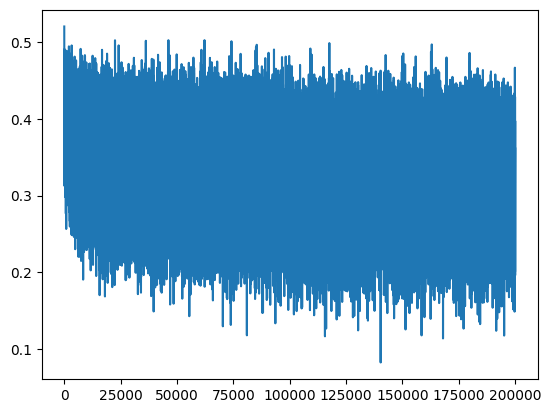

In [37]:
plt.plot(lossi)

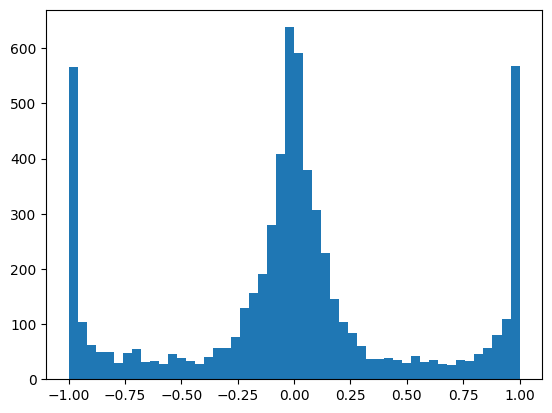

In [42]:
plt.hist(h.view(-1).tolist(), 50);

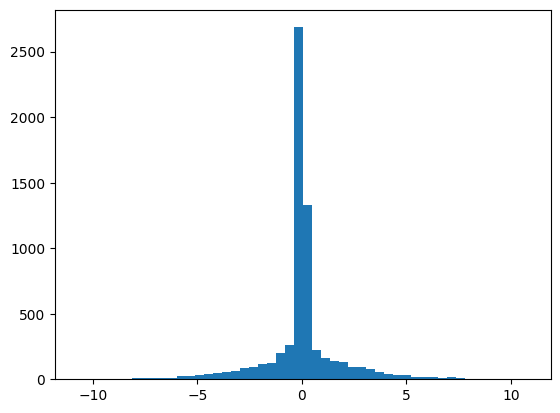

In [43]:
plt.hist(hpreact.view(-1).tolist(), 50);

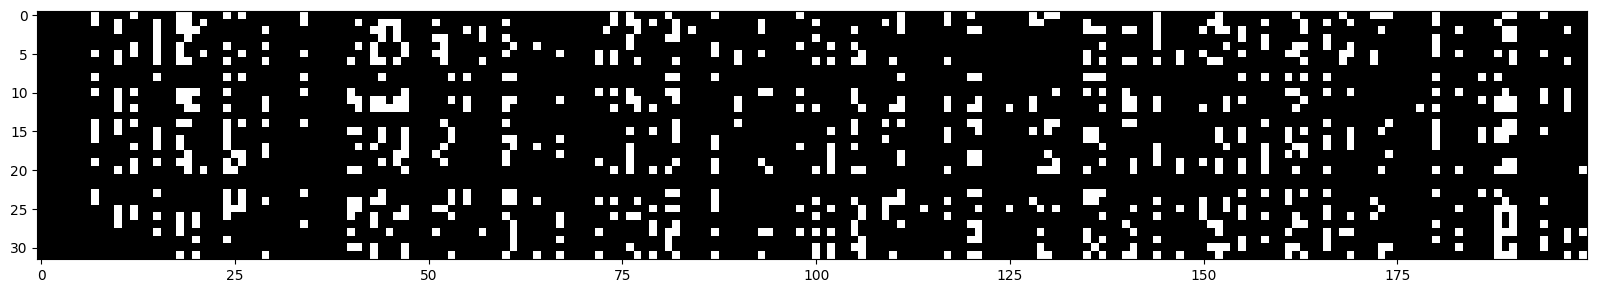

In [47]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [ ]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [66]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070265054702759
val 2.107935667037964


In [ ]:
# SUMMARY + PYTORCHIFYING -----------

## PyTorchifying — Linear & BatchNorm1d

In [90]:
# Karpathy's PyTorch-style implementation

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) #/ fan_in**0.5  # Kaiming init
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        # learnable parameters (scale & shift)
        self.gamma = torch.ones(dim)   # bngain
        self.beta  = torch.zeros(dim)  # bnbias
        # running stats (not trained via backprop, updated via EMA)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)             # batch mean
            xvar  = x.var(0, keepdim=True, unbiased=True) # batch variance, 用 var 是为了让 eps 加在正确的位置，保证数值稳定性。
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        # normalize
        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]  # only gamma & beta are trained via backprop

    
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [91]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.63, saturated: 2.62%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.37%
layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.75%
layer 14 (      Tanh): mean +0.00, std 0.63, saturated: 2.69%


Text(0.5, 1.0, 'activation distribution')

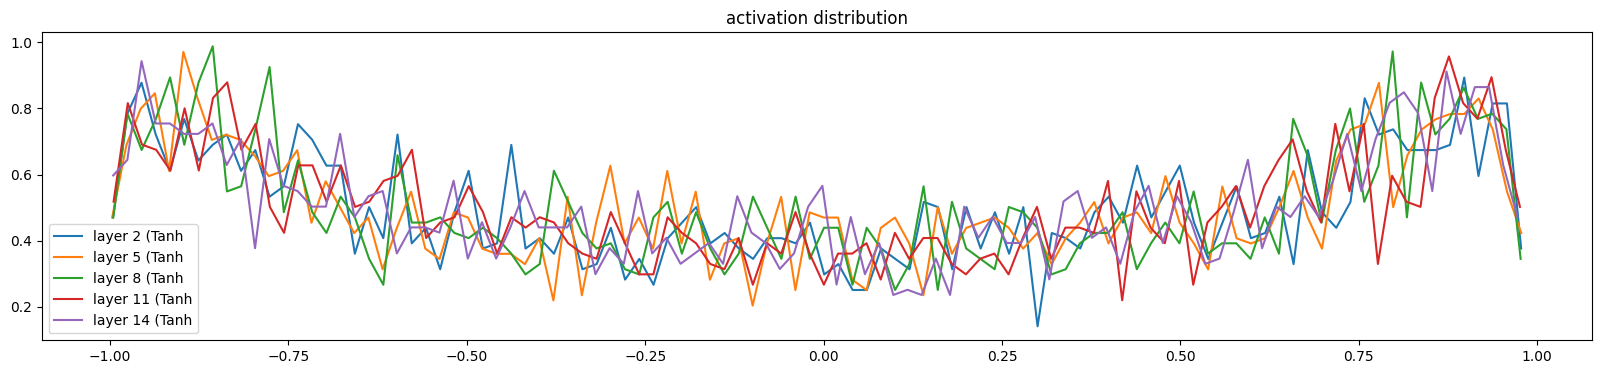

In [92]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % 
      (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

---

## Activation Distribution — 看 tanh 输出是否健康

这张图看的是每层 Tanh 的**激活值分布**（`layer.out`），诊断 tanh 是否饱和。

---

### 看什么

- **x 轴**：tanh 输出值，范围 `(-1, 1)`
- **峰集中在 0 附近**：健康，tanh 线性区，梯度 ≈ 1
- **两端堆积（靠近 ±1）**：危险，tanh 饱和区，梯度 ≈ 0

---

### Saturated 指标

代码里额外打印了每层的饱和比例：

```python
(t.abs() > 0.97).float().mean().item() * 100
```

`saturated` = tanh 输出绝对值 > 0.97 的神经元占比（经验阈值，约对应 `|hpreact| > 2`）。

| 饱和比例 | 含义 |
|----------|------|
| < 5% | 健康，梯度流动正常 |
| 10-20% | 偏高，初始化可能偏大 |
| > 50% | 危险，大量 dead neurons |

---

### 实验数据（Kaiming init + gain 5/3）

```
layer 1: mean -0.04, std 0.76, saturated 21.97%   ← 第一层偏高
layer 3: mean -0.01, std 0.72, saturated 11.00%
layer 5: mean +0.01, std 0.73, saturated 13.00%
layer 7: mean -0.05, std 0.73, saturated 13.34%
layer 9: mean +0.00, std 0.72, saturated 10.53%
```

第一层 22% 偏高，是因为 embedding 层直接接 Linear，没有经过 BN，分布控制不如后面层精确。后面几层 10-13% 相对稳定。

---

### 配合 Gradient Distribution 看

| 诊断图 | 看什么 | 能发现什么 |
|--------|--------|------------|
| **Activation dist** | tanh 输出分布 | 饱和 → dead neurons，梯度源头断掉 |
| **Gradient dist** | 梯度分布 | 消失/爆炸 → 各层学习速度失衡 |

两张图配套看：激活图显示"哪里出了问题"，梯度图显示"影响有多严重"。

### 关键点

| | Linear | BatchNorm1d |
|--|--------|-------------|
| 初始化 | Kaiming: `W / sqrt(fan_in)` | gamma=1, beta=0（恒等变换起点） |
| 可学习参数 | weight, bias | gamma, beta |
| running stats | 无 | running_mean, running_var（EMA 更新，不走 backprop） |
| 训练/推理区别 | 无 | `self.training` 控制用 batch stats 还是 running stats |

`eps=1e-5` 是防止除以 0 的小常数，加在 var 下面：`sqrt(var + eps)`

layer 2 (      Tanh): mean -0.000000, std 3.059682e-03
layer 5 (      Tanh): mean -0.000000, std 2.592222e-03
layer 8 (      Tanh): mean -0.000000, std 2.344924e-03
layer 11 (      Tanh): mean -0.000000, std 2.194399e-03
layer 14 (      Tanh): mean +0.000000, std 1.853027e-03


Text(0.5, 1.0, 'gradient distribution')

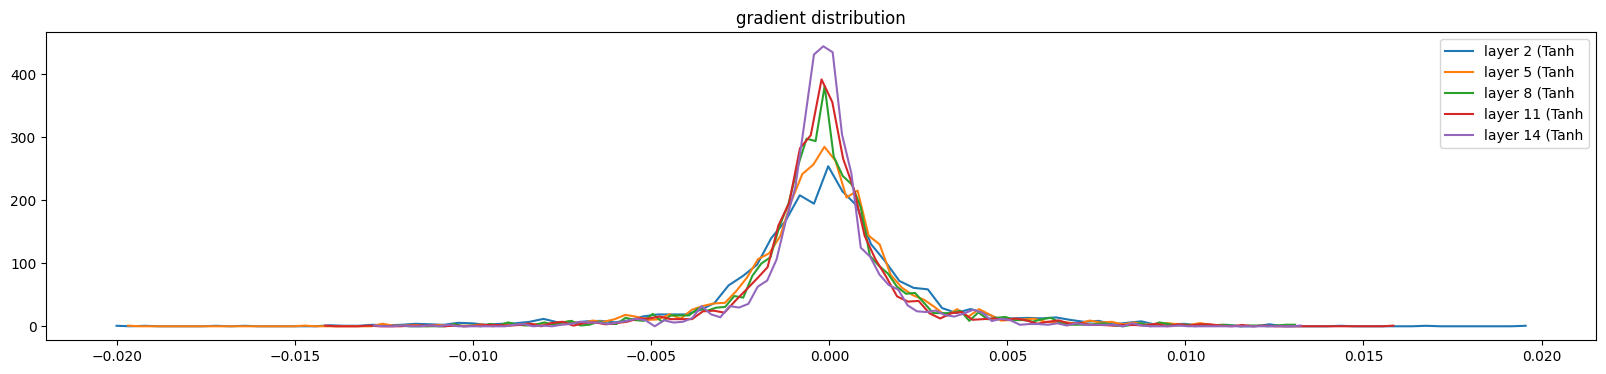

In [93]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

---

## Gradient Distribution — 三种情况

Karpathy 用这张图诊断初始化是否健康。画的是每层 Tanh 的**梯度分布**（`layer.out.grad`）。

---

### 看什么

- **x 轴**：梯度值大小
- **曲线宽窄**：std 越大 = 梯度越大 = 更新步子越大
- **各层是否重叠**：重叠 = 各层学习速度一致 = 健康

---

### 三种情况对比

| 情况 | std 趋势（layer 9 → layer 1） | 图像特征 | 后果 |
|------|-------------------------------|----------|------|
| **梯度消失** | 每层缩小 100x，靠近输入层 ≈ 0 | 前面层曲线压成竖线 | 前层完全不更新 |
| **梯度爆炸** | 每层放大 5-20x，靠近输入层暴宽 | 曲线散开成扇形 | loss 震荡，可能 NaN |
| **健康** | 各层 std 接近，差距 < 2x | 所有层曲线重叠 | 正常训练 |

---

### 实验数据

**梯度消失（权重 × 0.01，tanh 全饱和）：**
```
layer 9: std = 5.73e-04
layer 1: std = 1.28e-11   ← 差了 10⁷ 倍，前层完全学不动
```

**梯度爆炸（权重 × 10）：**
```
layer 9: std = 1.76e-03
layer 1: std = 3.83e-02   ← 差了 20 倍，步子太大，loss 震荡
```

**健康（Kaiming init + tanh gain 5/3）：**
```
layer 9: std = 2.31e-03
layer 1: std = 3.35e-03   ← 差了 1.5 倍，各层几乎重叠
```

---

### 关键洞察

> 梯度分布比 loss 曲线**更早**暴露问题。
> loss 还在"正常"范围时，梯度分布已经在告警了。

爆炸不一定立刻 NaN，有时是 loss 先震荡几百步然后才炸——大梯度把参数推到奇怪区域，下一步 loss 更高，梯度更大，正反馈循环。

---

### 解法

| 问题 | 解法 |
|------|------|
| 梯度消失 | Kaiming init / BatchNorm / Residual connections |
| 梯度爆炸 | 梯度裁剪（gradient clipping）/ 更小 lr / 正确初始化 |

weight   (27, 10) | mean +0.000000 | std 6.574892e-03 | grad:data ratio 6.569361e-03
weight  (30, 100) | mean -0.000003 | std 1.222243e-03 | grad:data ratio 7.155377e-04
weight (100, 100) | mean +0.000008 | std 6.805562e-04 | grad:data ratio 4.096763e-04
weight (100, 100) | mean +0.000002 | std 5.689898e-04 | grad:data ratio 3.389182e-04
weight (100, 100) | mean +0.000003 | std 4.910786e-04 | grad:data ratio 2.937398e-04
weight (100, 100) | mean +0.000001 | std 4.594584e-04 | grad:data ratio 2.745598e-04
weight  (100, 27) | mean +0.000003 | std 6.863168e-04 | grad:data ratio 4.164945e-04


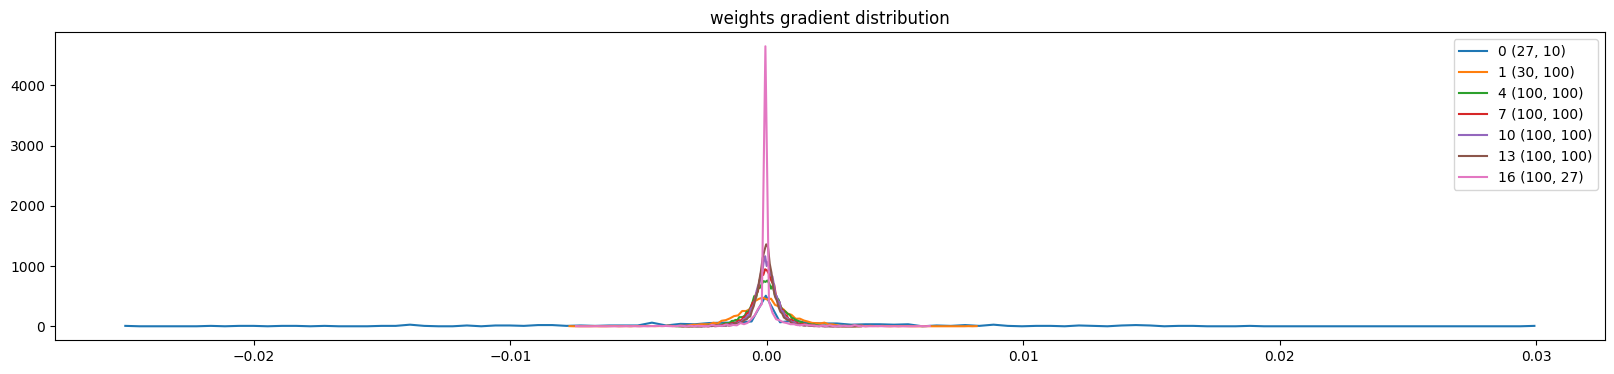

In [94]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

---

## Weights Gradient Distribution — grad:data ratio

这张图看的是**每个 weight 矩阵的梯度分布**，比前两张多了一个关键指标：

```python
t.std() / p.std()   # grad:data ratio = 梯度 std ÷ 权重 std
```

**含义：** 这一步更新，把这层的权重"搬动"了几成？

---

### 健康范围

| ratio | 状态 |
|-------|------|
| ~1e-3 | 理想 |
| ~1e-2 | 可接受 |
| ~1e-1 | 偏大，某层更新太激进 |

**各层 ratio 应该大致相近**，差距不超过 5-10 倍。

---

### 为什么 output 层 ratio 特别高（29%）

```python
layers[-1].weight *= 0.1   # output 层初始化时权重乘了 0.1
```

这一行是为了让 logits 接近 0（均匀概率，避免 hockey stick），但有副作用：

```
grad:data ratio = grad_std / weight_std
                = 0.02 / 0.007   ← weight 小了，分母变小
                = 0.29           ← ratio 爆了
```

grad 本身大小正常，只是 weight 太小让比值变大。

**结果：** 训练开头几百步 output 层更新幅度很大（每步 29%），weight 快速从"很小"长到正常量级，之后 ratio 自动恢复正常。代价只在开头。

---

### 对比：梯度消失（更坏的情况）

| | output 层 weight × 0.1 | 梯度消失 |
|--|----------------------|---------|
| **原因** | weight 小，grad 正常 | tanh 饱和，grad 被链式法则乘没了 |
| **grad 本身** | 正常大小 | 接近 0 |
| **ratio** | 大（29%） | 可能看起来正常 |
| **持续时间** | 开头几百步震荡，之后恢复 | 全程，永久坏 |

> output 层是 **weight 小但 grad 正常**，weight 会追上来。  
> 梯度消失是 **grad 本身就是 0**，weight 没有方向可以追。

---

## Grad:Data Ratio Over Time — ud 图

上一张图是某一步的梯度分布快照，这张图看的是 **ratio 随训练步数的变化趋势**。

```python
ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
```

- y 轴是 `log10(ratio)`，黑线是 `-3`（即理想值 `1e-3`）
- 每条彩线是一个 weight 矩阵，随训练步数的 ratio 变化

---

### 为什么有了 BN，`weight *= 5/3` 还是会影响 ratio

BN 只管 forward pass（归一化激活值），但：

```
ratio = grad_std / weight_std
```

**weight_std 本身没有被 BN 动过。**

```
weight *= 5/3
    ↓
weight_std 变大 5/3 倍
    ↓
grad_std 基本不变（BN 的 backward 归一化了它）
    ↓
ratio 变小，hidden 层的线都压在 -4 到 -5，远低于理想的 -3
```

**结论：有了 BN 之后，`weight *= 5/3` 不但没用，还会让 ratio 变小、学习变慢。应该删掉。**

---

### Weight 的值影响 Effective Learning Rate

lr 是固定的，但实际更新比例是：

```
更新比例 = lr × grad / weight
```

weight 本身越大，同样的 grad 冲击越小，这层实际学习速度越慢。

> lr 没变，但 weight 的初始值大小直接决定了这层实际的学习速度。

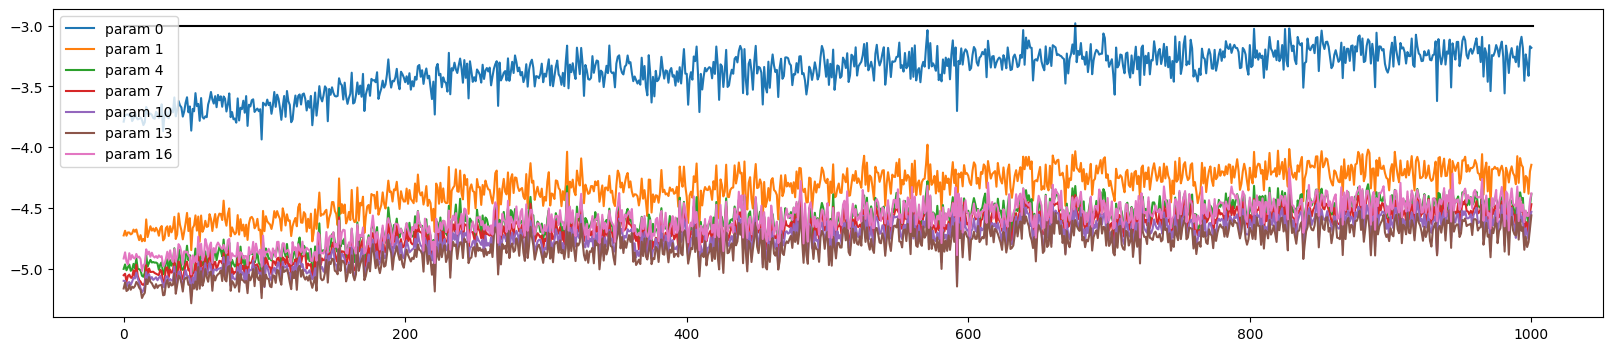

In [95]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Notes

- 

---

## Activation Functions & tanh 饱和问题

![activation functions](../docs/assets/activation_functions.png)

---

### tanh 的 backward

forward：
```
t = tanh(x)
```

backward（链式法则）：
```
x.grad = out.grad * (1 - t²)   ← local gradient
```

| t 的值 | local gradient `(1 - t²)` | 结果 |
|--------|--------------------------|------|
| t = 1  | 1 - 1 = **0** | 梯度归零，backward 断掉 |
| t = -1 | 1 - 1 = **0** | 梯度归零，backward 断掉 |
| t = 0  | 1 - 0 = **1** | 梯度原样通过，最理想 |

---

### 为什么 histogram 两端堆满是糟糕的

- W1 初始化太大 → hpreact 值很大 → tanh 把它们压到 ±1
- ±1 处梯度 = 0 → W1、b1、C 全部学不到东西
- 200 个 hidden neurons，大量是死的

Karpathy 原话：
> *"the more you are in the flat tails, the more the gradient is squashed"*

---

### 解决方法

缩小 W1 的初始化，让 hpreact 集中在 0 附近：

```python
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
# 默认是 * 1，太大了
```

这样 tanh 输入小，输出集中在 0，`(1 - t²)` 接近 1，梯度正常流动。

---

## Fan-in & Kaiming Initialization

**论文：** [Delving Deep into Rectifiers (He et al., 2015)](https://arxiv.org/abs/1502.01852) — Kaiming init 的原始论文

---

### fan-in 是什么

**fan-in** = 这一层的输入维度数，即有多少个输入连接到每个 neuron。

例如 `W1 = (30, 200)`，fan-in = 30。

---

### 为什么不除会出问题

```
y = x₁w₁ + x₂w₂ + ... + xₙwₙ

Var(y) = n * Var(w)     ← n 项累加，方差线性增长
std(y) = √n * std(w)
```

如果 `std(w) = 1`，`std(y) = √n`。每层都放大 √n 倍，10层之后 std 爆炸。

---

### 为什么除以 √fan_in 可以保持 std = 1

想让 `Var(y) = 1`：

```
n * Var(w) = 1
Var(w) = 1/n
std(w) = 1/√n
```

所以：
```python
W = torch.randn(...) / fan_in**0.5
```

---

### Xavier vs Kaiming

| 初始化 | 适用激活函数 | 公式 |
|--------|------------|------|
| **Xavier** | tanh / sigmoid | `std = 1/√fan_in` |
| **Kaiming** | ReLU | `std = √2/√fan_in` |

Kaiming 多了 `√2` 是因为 ReLU 把负数全砍掉，方差只剩一半，要补回来。

论文里的条件（公式10）：$\frac{1}{2} n_l \text{Var}[w_l] = 1$，解出 $\text{std} = \sqrt{2/n_l}$

---

### 可视化

![kaiming init](../docs/assets/kaiming_init.png)

- **左图（红）**：W ~ N(0,1)，矩阵乘法后 std 从 1 涨到 3.17
- **中图（蓝）**：W ~ N(0, 1/√n)，std 保持在 1
- **右图**：多层网络，坏初始化 std 指数爆炸，好初始化全程稳定在 1

---

### 代码

```python
# Xavier（tanh）
W1 = torch.randn((fan_in, fan_out)) / fan_in**0.5

# Kaiming（ReLU）
W1 = torch.randn((fan_in, fan_out)) * (2/fan_in)**0.5

# PyTorch 内置
torch.nn.init.kaiming_normal_(W1, nonlinearity='relu')
```

---

## Initialization Scale: The Full Chain

![init mindmap](../docs/assets/init_mindmap.png)

---

### tanh vs ReLU 的区别

| | tanh | ReLU |
|--|------|------|
| 问题 | 输入太大 → 输出挤在 ±1，梯度=0 | 负数截断为 0，一半 neuron dead |
| 叫做 | Saturation | Dead neurons |
| 修法 | Xavier init: `W / sqrt(fan_in)` | Kaiming init: `W * sqrt(2) / sqrt(fan_in)` |

---

### 一句话总结

> 初始化的目标是让每一层的激活值方差保持稳定，不随层数爆炸或消失，这样 forward 和 backward 都能正常工作。

---

## Batch Normalization — 两个容易混淆的点

---

### 核心做法

在进入激活函数之前强制归一化：

```
embcat @ W1 + b1        ← hpreact
      ↓
  BatchNorm              ← 强制 mean=0, std=1
      ↓
   tanh(hpreact)         ← 输入正常，不饱和
```

```python
mean = hpreact.mean(0, keepdim=True)          # (1, 200)
std  = hpreact.std(0, keepdim=True)           # (1, 200)
hpreact_norm = (hpreact - mean) / std         # mean=0, std=1
hpreact_bn   = gamma * hpreact_norm + beta    # 可学习的缩放和平移
```

---

### 点 1：同一个样本每次输出不同 → 这是好事

BN 的 mean/std 是用**当前 batch** 算的，不是固定值。

```
batch A: x 和 [a,b,c,...] 在一起 → mean=2.1 → h=0.32
batch B: x 和 [d,e,f,...] 在一起 → mean=3.7 → h=-0.45
```

同一个 x，两次输出不一样。看起来像 bug，实际上是 **regularization**：
- 每次输出带随机噪声 → 相当于数据增强 → 防止过拟合
- 效果类似 Dropout

---

### 点 2：为什么大家后来不喜欢 BN

| 问题 | 原因 |
|------|------|
| 训练和推理行为不一致 | 训练用 batch mean/std，推理只有 1 个样本，要用 running mean/std，容易出 bug |
| batch size 小时不稳定 | 2-4 个样本算出的 mean/std 不准，BN 失效 |
| 某些场景无法使用 | RNN、变长序列无法对 batch 维度归一化 |

---

### 替代方案

| 方法 | 适用场景 |
|------|----------|
| **Layer Norm** | Transformer 标配，对每个样本单独归一化，不依赖 batch |
| **Group Norm** | 视觉任务，batch size 小时用 |
| **Instance Norm** | 风格迁移 |

> GPT / Transformer 用 **Layer Norm**，没有 BN 的这些问题。

---

### 点 3：Calibrate BN — 解决训练/推理不一致

训练结束后，把整个训练集过一遍，算出**全局 mean/std**，作为推理时的固定值：

```python
with torch.no_grad():
    emb     = C[Xtr]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1          # 注意：没有 + b1，BN 的 beta 替代了偏置
    bnmean  = hpreact.mean(0, keepdim=True)   # 全局 mean
    bnstd   = hpreact.std(0, keepdim=True)    # 全局 std
```

| | mean/std 来源 | 样本数 |
|--|--------------|--------|
| **训练时** | 当前 mini-batch | 32 个 |
| **推理时** | calibrate 全局值 | 182580 个 |

---

## Batch Norm: Running Statistics & Scale/Shift

---

### Running Statistics（EMA）

训练时每个 mini-batch 都有自己的 mean/std，推理时需要一个稳定的全局估计值。
用 **Exponential Moving Average** 持续维护：

```python
bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
```

⚠️ 注意：两个系数必须加起来 = 1（`0.999 + 0.001`），否则是 bug。

| 系数 | 含义 |
|------|------|
| `0.999` | 保留 99.9% 的历史估计，变化缓慢稳定 |
| `0.001` | 吸收当前 batch 0.1% 的新信息 |

训练步数越多，running 值越接近真实全局 mean/std，且不会因为单个异常 batch 剧烈抖动。

---

### Running Stats vs Calibrate

| 方法 | 做法 | 时机 |
|------|------|------|
| **Running stats（EMA）** | 训练过程中每个 batch 持续更新 | 训练中 |
| **Calibrate** | 训练结束后整个训练集过一遍 | 训练后 |

PyTorch `nn.BatchNorm` 内置的就是 EMA 方式。

---

### Scale and Shift（bngain & bnbias）

BN 完整公式：

```python
bngain = torch.ones ((1, n_hidden))  # gamma，初始化为 1
bnbias = torch.zeros((1, n_hidden))  # beta， 初始化为 0

hpreact_norm = (hpreact - mean) / std      # 归一化：mean=0, std=1
h = bngain * hpreact_norm + bnbias         # scale and shift
```

**为什么初始化成 1 和 0：**

训练刚开始时让 BN 是恒等变换，不引入额外干扰：
```
h = 1 * hpreact_norm + 0 = hpreact_norm
```

随着训练进行，`bngain` 和 `bnbias` 会学偏离 1 和 0，调整到网络真正需要的分布。

**为什么需要这两个参数：**

BN 强制 mean=0, std=1，但这不一定是最优的。`bngain` 和 `bnbias` 让网络有能力恢复它需要的分布，不被死锁在 mean=0, std=1。

> 一句话：**初始化成 1 和 0 让训练开始时 BN 透明，之后让网络自己学出需要的 scale 和 shift。**

---

## Kaiming Init vs Batch Norm — 对比总结

| | Kaiming Init | Batch Norm |
|--|-------------|------------|
| **作用对象** | W（权重初始值） | hpreact（线性层输出） |
| **时机** | 训练开始前，一次性 | 每次 forward，持续有效 |
| **解决的问题** | h 分布极端 → dead neurons | hpreact 分布任意 → 激活饱和 |
| **方式** | W / sqrt(fan_in) → std ≈ 1 | (hpreact - mean) / std → mean=0, std=1 |
| **可调整性** | 无，固定 | bngain & bnbias 可学习，network 自己选分布 |
| **训练后还有效吗** | ❌ 训练后不再管 | ✅ 持续归一化 |

---

### 流程对比

```
Kaiming Init
────────────
W = randn(...) / sqrt(fan_in)
         ↓
hpreact = embcat @ W          std ≈ 1
         ↓
h = tanh(hpreact)             不饱和 ✅


Batch Norm
──────────
hpreact = embcat @ W          std 任意
         ↓
归一化: (hpreact - mean) / std   → mean=0, std=1
         ↓
scale & shift: bngain * hpreact_norm + bnbias
         ↓               ↑
         └── network 自己学出需要的分布
         ↓
h = tanh(hpreact)             不饱和 ✅
```

---

> **一句话：** Kaiming 是在进门前打扫一次，BN 是装了一个自动清洁系统，每次都保持干净。

---

## BN Running Stats: Momentum 的影响

PyTorch `nn.BatchNorm` 的更新公式：

```
running = (1 - momentum) × running + momentum × x_new
```

⚠️ PyTorch 的 momentum 定义和手写版系数**方向相反**：

```python
# 手写版
bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani

# 对应 PyTorch momentum = 0.001
nn.BatchNorm1d(n_hidden, momentum=0.001)
```

---

### Momentum 取值的影响

| momentum | 效果 | 问题 |
|----------|------|------|
| **太大**（如 0.9） | running ≈ 当前 batch，历史丢失 | 推理时 mean/std 不稳定，不代表全局 |
| **太小**（如 0.0001） | 变化极慢 | 需要极多步数才能收敛到真实全局值 |
| **默认 0.1** | 平衡新旧信息 | PyTorch 默认值，大多数情况够用 |

---

> **核心：** momentum 太大 → running stats 一直抖动 → 推理时的 mean/std 不准 → BN 失效。

---

## Karpathy 课程总结 — Part 3

### 做了的三件事

**1. Batch Normalization**
第一个"现代创新"，在进入激活函数前强制归一化，帮助稳定深层网络训练。

**2. PyTorchifying**
把代码包成 `Linear`、`BatchNorm1d`、`Tanh` 模块，像乐高一样堆叠。
他写的 API 和 `torch.nn` 完全一致——在前面加 `nn.` 就能直接换成 PyTorch 官方版本，不用改任何逻辑。

**3. 诊断工具**
三张图：
- Activation distribution（forward pass，看 tanh 是否饱和）
- Gradient distribution（backward pass，看梯度是否消失/爆炸）
- Weights gradient distribution + **update:data ratio**（看各层学习速度是否均衡）

实际使用时看 **ratio 随时间的变化趋势**，不看单张快照。理想值 `1e-3`（log scale `-3`）。太高 → lr 太大，太低 → lr 太小。

---

### 没做的一件事

**没有提升模型性能。**

加了 BN 之后结果和之前差不多——因为现在瓶颈**不是优化，而是 context 太短**（只看 3 个字符预测第 4 个）。要继续提升需要更长 context，也就是 **RNN 或 Transformer**，这是后续课程的内容。

---

### 他的诚实承认

> *"我们还没有真正解决初始化问题，也没有解决反向传播问题，这仍然是活跃的研究领域。"*

这节课的目的是**介绍诊断工具**，告诉你怎么判断网络是否健康。背后完整的数学直觉（为什么改 gain 要改 lr，每层 backward 到底在做什么）没有深入讲，在学界也还没有完全解决。